In [2]:
!pip install pandas
!pip install matplotlib
!pip install wordcloud
!pip install --upgrade gensim
!pip install seaborn
!pip install tensorflow
!pip install tensorflow-addons

Requirement already up-to-date: gensim in c:\python38\lib\site-packages (3.8.3)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import multiprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import time
import seaborn as sns
import tensorflow as tf
import random
import matplotlib.image  as mpimg
import io
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import tensorflow_addons as tfa
from gensim.models import Word2Vec

In [4]:
df = pd.read_csv("NewsFakeCOVID-19.csv")

real = pd.read_csv("NewsRealCOVID-19_tweets_ready.csv")
fake = pd.read_csv("NewsFakeCOVID-19_tweets_ready.csv")

real_news = pd.read_csv("NewsRealCOVID-19.csv")
fake_news = pd.read_csv("NewsFakeCOVID-19.csv")

fake_lstm = fake
real_lstm = real

fake_news_lstm = fake_news
real_news_lstm = real_news

fake['target'] = 'fake'
real['target'] = 'real'

fake_news['target'] = 'fake'
real_news['target'] = 'real'

fake_lstm['target'] = 0
real_lstm['target'] = 1

fake_news_lstm['target'] = 0
real_news_lstm['target'] = 1

In [6]:
real.head()

,coordinates,created_at,hashtags,media,urls,favorite_count,id,in_reply_to_screen_name,in_reply_to_status_id,in_reply_to_user_id,...,user_followers_count,user_friends_count,user_listed_count,user_location,user_name,user_screen_name.1,user_statuses_count,user_time_zone,user_urls,user_verified
0,NaN,Thu Apr 09 18:35:28 +0000 2020,NaN,NaN,http://drcarolehhaynes.com/index.php/articles/...,0,1248318630842040331,NaN,NaN,NaN,...,117,160,12,Florida,Judy Wolfersberger,wolfeyjr,8894,NaN,NaN,False
1,NaN,Tue Apr 14 20:58:11 +0000 2020,NaN,NaN,https://aviationdaily.news/2020/04/11/pentagon...,0,1250166483570905088,NaN,NaN,NaN,...,268,463,0,NaN,SEASON,AnonSeasoned,2967,NaN,NaN,False
2,NaN,Tue Apr 14 20:05:49 +0000 2020,NaN,NaN,NaN,0,1250153305524834309,NaN,NaN,NaN,...,1460,2090,2,Maryland,Jean Wojcik,JeanWoj,40155,NaN,NaN,False
3,NaN,Thu Apr 09 15:14:57 +0000 2020,NaN,NaN,http://drcarolehhaynes.com/index.php/articles/...,3,1248268168042295297,NaN,NaN,NaN,...,74056,65621,237,"Gamecock Country, SC",Carolina Girl #MAGA #ChumpForTrump,carolinagirl63,53523,NaN,NaN,False
4,NaN,Sun Apr 12 03:32:57 +0000 2020,NaN,NaN,http://aviationdaily.news/2020/04/11/pentagon-...,0,1249178669056131073,NaN,NaN,NaN,...,1152,2007,258,cyberspace,ARYAN®,gladeolie,211893,NaN,http://www.zedie.wordpress.com,False


In [5]:
fake.head()

,coordinates,created_at,hashtags,media,urls,favorite_count,id,in_reply_to_screen_name,in_reply_to_status_id,in_reply_to_user_id,...,user_friends_count,user_listed_count,user_location,user_name,user_screen_name.1,user_statuses_count,user_time_zone,user_urls,user_verified,target
0,NaN,Thu Apr 09 18:35:28 +0000 2020,NaN,NaN,http://drcarolehhaynes.com/index.php/articles/...,0,1248318630842040331,NaN,NaN,NaN,...,160,12,Florida,Judy Wolfersberger,wolfeyjr,8894,NaN,NaN,False,0
1,NaN,Tue Apr 14 20:58:11 +0000 2020,NaN,NaN,https://aviationdaily.news/2020/04/11/pentagon...,0,1250166483570905088,NaN,NaN,NaN,...,463,0,NaN,SEASON,AnonSeasoned,2967,NaN,NaN,False,0
2,NaN,Tue Apr 14 20:05:49 +0000 2020,NaN,NaN,NaN,0,1250153305524834309,NaN,NaN,NaN,...,2090,2,Maryland,Jean Wojcik,JeanWoj,40155,NaN,NaN,False,0
3,NaN,Thu Apr 09 15:14:57 +0000 2020,NaN,NaN,http://drcarolehhaynes.com/index.php/articles/...,3,1248268168042295297,NaN,NaN,NaN,...,65621,237,"Gamecock Country, SC",Carolina Girl #MAGA #ChumpForTrump,carolinagirl63,53523,NaN,NaN,False,0
4,NaN,Sun Apr 12 03:32:57 +0000 2020,NaN,NaN,http://aviationdaily.news/2020/04/11/pentagon-...,0,1249178669056131073,NaN,NaN,NaN,...,2007,258,cyberspace,ARYAN®,gladeolie,211893,NaN,http://www.zedie.wordpress.com,False,0


In [7]:
fake_news.head()

,Unnamed: 0,type,fact_check_url,archieve,news_url,news_url2,news_url3,news_url4,news_url5,title,newstitle,content,abstract,publish_date,meta_keywords,target
0,623,post,https://www.factcheck.org/2020/07/face-mask-ex...,http://archive.is/LC508,https://www.facebook.com/tednugent/photos/a.10...,NaN,NaN,NaN,NaN,A “face mask exempt card” shared on social med...,"""Ted Nugent""",snag limbrats that daddy 22s out of the toweri...,ted nugent added a new photo ..,NaN,"""""",0
1,624,post,https://www.factcheck.org/2020/07/video-presen...,http://archive.is/l3qLv,https://www.facebook.com/jeff.neff.528/videos/...,NaN,NaN,NaN,NaN,A test on video with a gas detector shows that...,"""Jeff""",see more of jeff neff on facebook.,face masks you decide. this is worth a few min...,NaN,"""""",0
2,625,post,https://www.factcheck.org/2020/06/painting-of-...,http://archive.is/vv6OB,https://twitter.com/SexCounseling/status/12764...,https://www.facebook.com/photo.php?fbid=102138...,https://www.facebook.com/112390917148814/posts...,NaN,NaN,A painting depicting children in face masks wa...,"""""",we 've detected that javascript is disabled in...,NaN,NaN,"""""",0
3,626,article,https://healthfeedback.org/claimreview/contrar...,https://archive.is/51Jn0,https://www.wakingtimes.com/2020/05/15/bill-ga...,NaN,NaN,NaN,NaN,According to Bill Gates the COVID-19 RNA vacci...,"""403 Forbidden""",NaN,NaN,NaN,"""""",0
4,627,post,https://www.factcheck.org/2020/06/meme-misrepr...,NaN,https://www.facebook.com/photo.php?fbid=424048...,NaN,NaN,NaN,NaN,Meme shows Florida Surgeon General saying: Eve...,"""Jeff Cloud""",see more of jeff cloud on facebook.,it 's all coming out now .....,NaN,"""""",0


In [6]:
real_news.head()

,Unnamed: 0,type,fact_check_url,news_url,title,newstitle,content,abstract,publish_date,meta_keywords,target
0,1555,article,healthline.com,https://www.healthline.com/health-news/how-to-...,How to Enjoy the Fourth of July Weekend Amid t...,"""How to Enjoy Fourth of July Weekend Amid the ...",experts recommend everyone avoid large gatheri...,experts recommend everyone avoid large gatheri...,NaN,"""COVID19 coronavirus prevention advice July 4 ...",1
1,1556,article,healthline.com,https://www.healthline.com/health-news/cdc-exp...,CDC Expands List of Those with Higher COVID-19...,"""CDC Expands List of Those with Higher COVID-1...",experts say the key is to stay in the know and...,officials at the centers for disease control a...,NaN,"""CDC list expanded COVID-19 coronavirus higher...",1
2,1557,article,healthline.com,https://www.healthline.com/health-news/feds-wa...,Feds Warn That Face Mask ‘Exemption’ Cards Are...,"""Feds Warn That Face Mask ‘Exemption’ Cards Ar...",some people have reportedly been presenting fa...,reports of people presenting cards that claim ...,NaN,"""covid 19, coronavirus, face mask exemption ca...",1
3,1558,article,healthline.com,https://www.healthline.com/health-news/experts...,Experts Confident Biden’s COVID-19 Response Co...,"""Experts Confident Biden's COVID-19 Response C...",medical experts say they believe bidens plan t...,medical experts say they believe bidens plan t...,NaN,"""covid 19, coronavirus, testing and tracing""",1
4,1559,article,healthline.com,https://www.healthline.com/health-news/heres-e...,Here’s Exactly Where We Are with Vaccines and ...,"""Where We're at with Vaccines and Treatments f...",scientists around the world are working on a n...,scientists around the world are working on a n...,NaN,"""covid19 coronavirus outbreak research progres...",1


In [48]:
count = CountVectorizer()
bag_of_words = count.fit_transform(df['text'].values.astype('U'))
sum_words = bag_of_words.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in count.fit(df['text'].values.astype('U')).vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

article_list=["is", "of", "the", "to", "on", "in", "and", "by", "with", "nan", "a", "this", "it", "for"]

words = []

# for word in words_freq:
#     if not word[0] in article_list:
#         words.append(word)

# for word, freq in words_freq[:40]:
#     print(word, ": ", freq, sep="")

feature_names = count.get_feature_names()
bow = pd.DataFrame(words_freq, columns=["word", "frequency"])

# bow.plot(kind='bar',x='word',y='frequency')

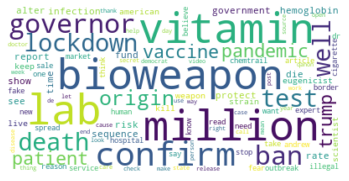

In [10]:
wlist = bow['word'].values.flatten()
wlist = " ".join([str(item) for item in wlist])

wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(wlist)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [13]:
sent = [row.split() for row in real['text']]
w2v_model = Word2Vec(sent, min_count=20, window=2, size=300,sample=6e-5, alpha=0.03, min_alpha=0.0007, negative=20, workers=1)

w2v_model.train(sent, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

(23790863, 60395700)

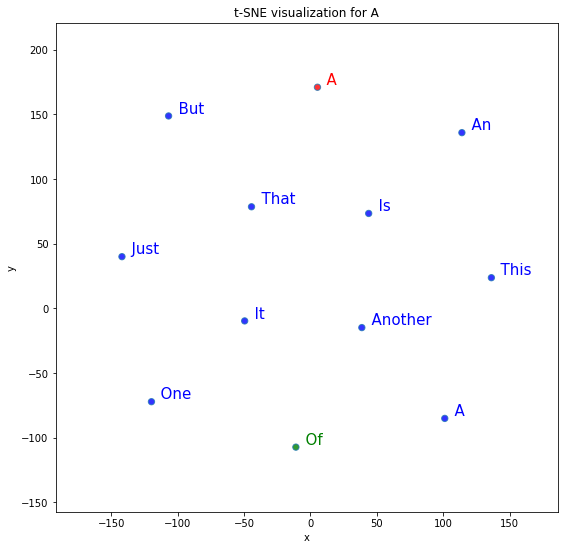

In [12]:
def tsnescatterplot(model, word, list_names):
    """ Plot in seaborn the results from the t-SNE dimensionality reduction algorithm of the vectors of a query word,
    its list of most similar words, and a list of words.
    """
    arrays = np.empty((0, 300), dtype='f')
    word_labels = [word]
    color_list  = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)
    
    # gets list of most similar words
    close_words = model.wv.most_similar([word])
    
    # adds the vector for each of the closest words to the array
    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)
    
    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)
        
    # Reduces the dimensionality from 300 to 50 dimensions with PCA
    reduc = PCA(n_components=12).fit_transform(arrays)
    
    # Finds t-SNE coordinates for 2 dimensions
    np.set_printoptions(suppress=True)
    
    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)
    
    # Sets everything up to plot
    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})
    
    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)
    
    # Basic plot
    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                 }
                    )
    
    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
         p1.text(df["x"][line],
                 df['y'][line],
                 '  ' + df["words"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 color=df['color'][line],
                 weight='normal'
                ).set_size(15)

    
    plt.xlim(Y[:, 0].min()-50, Y[:, 0].max()+50)
    plt.ylim(Y[:, 1].min()-50, Y[:, 1].max()+50)
            
    plt.title('t-SNE visualization for {}'.format(word.title()))
    
tsnescatterplot(w2v_model, 'a', ['of'])

In [16]:

news = pd.concat([fake_news, real_news]).reset_index(drop = True)
tweets = pd.concat([fake, real]).reset_index(drop = True)

news_lstm = pd.concat([fake_news_lstm, real_news_lstm]).reset_index(drop = True)
tweets_lstm = pd.concat([fake_lstm, real_lstm]).reset_index(drop = True)

x_train,x_test,y_train,y_test = train_test_split(tweets['text'].values.astype('U'), tweets.target,train_size=0.01, test_size=0.9, random_state=1)
a_train,a_test,b_train,b_test = train_test_split(news['title'].values.astype('U'), news.target, test_size=0.2, random_state=1)

# x_train_lstm, x_test_lstm, y_train_lstm, y_test_lstm = train_test_split(tweets_lstm['text'].values.astype('U'), tweets.target,train_size=0.01, test_size=0.9, random_state=1)
# a_train_lstm, a_test_lstm, b_train_lstm, b_test_lstm = train_test_split(news_lstm['title'].values.astype('U'), news.target, test_size=0.2, random_state=1)

In [18]:
#Logistic regression classification
pipe1 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', LogisticRegression())])

model_lr = pipe1.fit(a_train, b_train)
lr_pred = model_lr.predict(a_test)

print("Accuracy of Logistic Regression Classifier for Articles: {}%".format(round(accuracy_score(b_test, lr_pred)*100,2)))
print("\nConfusion Matrix of Logistic Regression Classifier:\n")
print(confusion_matrix(b_test, lr_pred))
print("\nCLassification Report of Logistic Regression Classifier:\n")
print(classification_report(b_test, lr_pred))

Accuracy of Logistic Regression Classifier for Articles: 87.46%

Confusion Matrix of Logistic Regression Classifier:

[[ 22  34]
 [  1 222]]

CLassification Report of Logistic Regression Classifier:

              precision    recall  f1-score   support

           0       0.96      0.39      0.56        56
           1       0.87      1.00      0.93       223

    accuracy                           0.87       279
   macro avg       0.91      0.69      0.74       279
weighted avg       0.89      0.87      0.85       279



In [20]:
#Support Vector Machine classification
pipe2 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', LinearSVC())])
model_svc = pipe2.fit(a_train, b_train)
svc_pred = model_svc.predict(a_test)

print("Accuracy of SVM Classifier for Articles: {}%".format(round(accuracy_score(b_test, svc_pred)*100,2)))
print("\nConfusion Matrix of SVM Classifier:\n")
print(confusion_matrix(b_test, svc_pred))
print("\nClassification Report of SVM Classifier:\n")
print(classification_report(b_test, svc_pred))

Accuracy of SVM Classifier for Articles: 91.76%

Confusion Matrix of SVM Classifier:

[[ 39  17]
 [  6 217]]

Classification Report of SVM Classifier:

              precision    recall  f1-score   support

           0       0.87      0.70      0.77        56
           1       0.93      0.97      0.95       223

    accuracy                           0.92       279
   macro avg       0.90      0.83      0.86       279
weighted avg       0.92      0.92      0.91       279



In [21]:
#Naive-Bayes classification
pipe3 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', MultinomialNB())])

model_nb = pipe3.fit(a_train, b_train)
nb_pred = model_nb.predict(a_test)

print("Accuracy of Naive Bayes Classifier for Articles: {}%".format(round(accuracy_score(b_test, nb_pred)*100,2)))
print("\nConfusion Matrix of Naive Bayes Classifier:\n")
print(confusion_matrix(b_test, nb_pred))
print("\nClassification Report of Naive Bayes Classifier:\n")
print(classification_report(b_test, nb_pred))

Accuracy of Naive Bayes Classifier for Articles: 82.44%

Confusion Matrix of Naive Bayes Classifier:

[[  7  49]
 [  0 223]]

Classification Report of Naive Bayes Classifier:

              precision    recall  f1-score   support

           0       1.00      0.12      0.22        56
           1       0.82      1.00      0.90       223

    accuracy                           0.82       279
   macro avg       0.91      0.56      0.56       279
weighted avg       0.86      0.82      0.76       279



In [22]:
#Random-Forest Classification
pipe4 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', RandomForestClassifier())])

model_rf = pipe4.fit(a_train, b_train)
rf_pred = model_rf.predict(a_test)

print("Accuracy of Random Forest Classifier for Articles: {}%".format(round(accuracy_score(b_test, rf_pred)*100,2)))
print("\nConfusion Matrix of Random Forest Classifier:\n")
print(confusion_matrix(b_test, rf_pred))
print("\nClassification Report of Random Forest Classifier:\n")
print(classification_report(b_test, rf_pred))

Accuracy of Random Forest Classifier for Articles: 89.61%

Confusion Matrix of Random Forest Classifier:

[[ 28  28]
 [  1 222]]

Classification Report of Random Forest Classifier:

              precision    recall  f1-score   support

           0       0.97      0.50      0.66        56
           1       0.89      1.00      0.94       223

    accuracy                           0.90       279
   macro avg       0.93      0.75      0.80       279
weighted avg       0.90      0.90      0.88       279



In [19]:
#Logistic regression classification
pipe1 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', LogisticRegression())])

model_lr = pipe1.fit(x_train, y_train)
lr_pred = model_lr.predict(x_test)

print("Accuracy of Logistic Regression Classifier for Tweets: {}%".format(round(accuracy_score(y_test, lr_pred)*100,2)))
print("\nConfusion Matrix of Logistic Regression Classifier:\n")
print(confusion_matrix(y_test, lr_pred))
print("\nCLassification Report of Logistic Regression Classifier:\n")
print(classification_report(y_test, lr_pred))

Accuracy of Logistic Regression Classifier for Tweets: 91.24%

Confusion Matrix of Logistic Regression Classifier:

[[  384  7116]
 [    0 73687]]

CLassification Report of Logistic Regression Classifier:

              precision    recall  f1-score   support

           0       1.00      0.05      0.10      7500
           1       0.91      1.00      0.95     73687

    accuracy                           0.91     81187
   macro avg       0.96      0.53      0.53     81187
weighted avg       0.92      0.91      0.87     81187



In [212]:
#Support Vector classification
pipe2 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', LinearSVC())])
model_svc = pipe2.fit(x_train, y_train)
svc_pred = model_svc.predict(x_test)

print("Accuracy of SVM Classifier for Tweets: {}%".format(round(accuracy_score(y_test, svc_pred)*100,2)))
print("\nConfusion Matrix of SVM Classifier:\n")
print(confusion_matrix(y_test, svc_pred))
print("\nClassification Report of SVM Classifier:\n")
print(classification_report(y_test, svc_pred))

Accuracy of SVM Classifier: 97.72%

Confusion Matrix of SVM Classifier:

[[ 5649  1851]
 [    0 73687]]

Classification Report of SVM Classifier:

              precision    recall  f1-score   support

        fake       1.00      0.75      0.86      7500
        true       0.98      1.00      0.99     73687

    accuracy                           0.98     81187
   macro avg       0.99      0.88      0.92     81187
weighted avg       0.98      0.98      0.98     81187



In [211]:
#Naive-Bayes classification
pipe3 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', MultinomialNB())])

model_nb = pipe3.fit(x_train, y_train)
nb_pred = model_nb.predict(x_test)

print("Accuracy of Naive Bayes Classifier for Tweets: {}%".format(round(accuracy_score(y_test, nb_pred)*100,2)))
print("\nConfusion Matrix of Naive Bayes Classifier:\n")
print(confusion_matrix(y_test, nb_pred))
print("\nClassification Report of Naive Bayes Classifier:\n")
print(classification_report(y_test, nb_pred))

Accuracy of Naive Bayes Classifier: 91.13%

Confusion Matrix of Naive Bayes Classifier:

[[  295  7205]
 [    0 73687]]

Classification Report of Naive Bayes Classifier:

              precision    recall  f1-score   support

        fake       1.00      0.04      0.08      7500
        true       0.91      1.00      0.95     73687

    accuracy                           0.91     81187
   macro avg       0.96      0.52      0.51     81187
weighted avg       0.92      0.91      0.87     81187



In [23]:
#Random-Forest
pipe4 = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('model', RandomForestClassifier())])

model_rf = pipe4.fit(x_train, y_train)
rf_pred = model_rf.predict(x_test)

print("Accuracy of Random Forest Classifier for Tweets: {}%".format(round(accuracy_score(y_test, rf_pred)*100,2)))
print("\nConfusion Matrix of Random Forest Classifier:\n")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report of Random Forest Classifier:\n")
print(classification_report(y_test, rf_pred))

Accuracy of Random Forest Classifier for Tweets: 96.76%

Confusion Matrix of Random Forest Classifier:

[[ 4867  2633]
 [    0 73687]]

Classification Report of Random Forest Classifier:

              precision    recall  f1-score   support

           0       1.00      0.65      0.79      7500
           1       0.97      1.00      0.98     73687

    accuracy                           0.97     81187
   macro avg       0.98      0.82      0.88     81187
weighted avg       0.97      0.97      0.96     81187



In [25]:
# Retrieve the data
news_lstm = news_lstm.fillna(' ')
tweets_lstm = tweets_lstm.fillna(' ')
tweets_lstm.count()

coordinates                   90207
created_at                    90207
hashtags                      90207
media                         90207
urls                          90207
favorite_count                90207
id                            90207
in_reply_to_screen_name       90207
in_reply_to_status_id         90207
in_reply_to_user_id           90207
lang                          90207
place                         90207
possibly_sensitive            90207
retweet_count                 90207
retweet_id                    90207
retweet_screen_name           90207
source                        90207
text                          90207
tweet_url                     90207
user_created_at               90207
user_screen_name              90207
user_default_profile_image    90207
user_description              90207
user_favourites_count         90207
user_followers_count          90207
user_friends_count            90207
user_listed_count             90207
user_location               

In [26]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(tweets_lstm['text'].values.astype('U'))
word_index = tokenizer.word_index
vocab_size=len(word_index)
print(vocab_size)

# Padding data

sequences = tokenizer.texts_to_sequences(tweets_lstm['text'])
padded = pad_sequences(sequences, maxlen=500, padding='post', truncating='post')


177065


In [27]:
tokenizer_news = Tokenizer()
tokenizer_news.fit_on_texts(news_lstm['title'].values.astype('U'))
word_index_news = tokenizer_news.word_index
vocab_size_news=len(word_index_news)
print(vocab_size)

sequences_news = tokenizer_news.texts_to_sequences(news_lstm['title'])
padded_news = pad_sequences(sequences_news, maxlen=500, padding='post', truncating='post')

177065


In [44]:
split = 0.2
split_n = int(round(len(padded)*(1-split),0))

train_data = padded[:split_n]
train_labels = tweets['target'].values[:split_n]
test_data = padded[split_n:]
test_labels = tweets['target'].values[split_n:]

test_split = 0.2
split_n_news = int(round(len(padded_news)*(1-test_split),0))

train_data_news = padded_news[:split_n_news]
train_labels_news = news['target'].values[:split_n_news]
test_data_news = padded_news[split_n_news:]
test_labels_news = news['target'].values[split_n_news:]

In [31]:
# Import tensor representations for words
embeddings_index = {};
with open('glove.6B.100d.txt', encoding="utf8") as f:
    for line in f:
        values = line.split();
        word = values[0];
        coefs = np.asarray(values[1:], dtype='float32');
        embeddings_index[word] = coefs;
print(len(coefs))

embeddings_matrix = np.zeros((vocab_size+1, 100));
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word);
    if embedding_vector is not None:
        embeddings_matrix[i] = embedding_vector;

100


In [32]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size+1, 100, weights=[embeddings_matrix], trainable=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=4),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.LSTM(20),
    tf.keras.layers.Dropout(0.2),  
    tf.keras.layers.Dense(512),
    tf.keras.layers.Dropout(0.3),  
    tf.keras.layers.Dense(256),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 100)         17706600  
_________________________________________________________________
dropout (Dropout)            (None, None, 100)         0         
_________________________________________________________________
conv1d (Conv1D)              (None, None, 64)          32064     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, None, 64)          0         
_________________________________________________________________
lstm (LSTM)                  (None, None, 20)          6800      
_________________________________________________________________
lstm_1 (LSTM)                (None, 20)                3280      
_________________________________________________________________
dropout_1 (Dropout)          (None, 20)                0

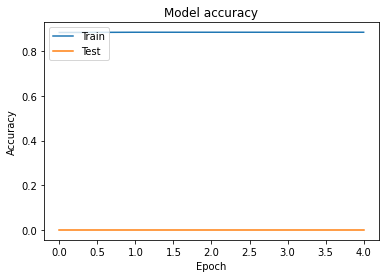

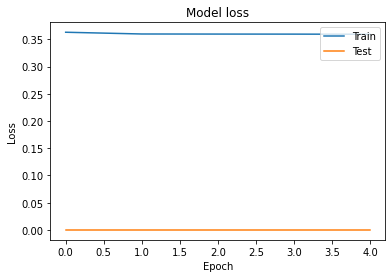

In [33]:

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy', tf.metrics.Recall(), tf.keras.metrics.Precision(), tfa.metrics.F1Score(1)])
model.summary()

history = model.fit(train_data, train_labels, epochs=5, batch_size=100, validation_data=[test_data, test_labels])

print("Training Complete")


In [37]:
print("Evaluate on test data")
results = model.evaluate(test_data, test_labels, batch_size=10)
print("test loss, test acc:", results)

Evaluate on test data
1805/1805 [==============================] - 21s 12ms/step - loss: 0.1305 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - f1_score: 1.00001s - loss: 0.1305 - accuracy: 
test loss, test acc: [0.1305338740348816, 1.0, 1.0, 1.0, array([1.], dtype=float32)]


In [45]:
model_news = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size+1, 100, weights=[embeddings_matrix], trainable=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=4),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.LSTM(20),
    tf.keras.layers.Dropout(0.2),  
    tf.keras.layers.Dense(512),
    tf.keras.layers.Dropout(0.3),  
    tf.keras.layers.Dense(256),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [46]:
model_news.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy', tf.metrics.Recall(), tf.keras.metrics.Precision(), tfa.metrics.F1Score(1)])
model_news.summary()

history = model_news.fit(train_data_news, train_labels_news, epochs=5, batch_size=10, validation_data=[test_data_news, test_labels_news])

print("Training Complete")


Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, None, 100)         17706600  
_________________________________________________________________
dropout_9 (Dropout)          (None, None, 100)         0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, None, 64)          32064     
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, None, 64)          0         
_________________________________________________________________
lstm_6 (LSTM)                (None, None, 20)          6800      
_________________________________________________________________
lstm_7 (LSTM)                (None, 20)                3280      
_________________________________________________________________
dropout_10 (Dropout)         (None, 20)               

In [47]:
print("Evaluate on test data")
results = model_news.evaluate(test_data_news, test_labels_news, batch_size=10)
print("test loss, test acc:", results)

Evaluate on test data
28/28 [==============================] - 0s 11ms/step - loss: 0.2938 - accuracy: 1.0000 - recall_3: 1.0000 - precision_3: 1.0000 - f1_score: 1.0000
test loss, test acc: [0.2937621474266052, 1.0, 1.0, 1.0, array([1.], dtype=float32)]
